In [13]:
import torch
import os
from torch import nn
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import numpy as np




class Tetris_shapes(nn.Module):
    def __init__(self,input_features, output_features, hidden_units):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(nn.Linear(in_features=input_features, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=output_features))

        for layer in self.linear_layer_stack:
          if isinstance(layer, nn.Linear):
            nn.init.kaiming_uniform_(layer.weight)



    def forward(self, x):
        return self.linear_layer_stack(x)


model_linear_correlated_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=10)

model_linear_correlated_data_dict = torch.load("/content/linear_1d1p_0.0125_correlated.pt")


def collect_activation(model,x):
  x= torch.tensor(np.array(x, dtype=np.float32))
  with torch.no_grad():
    layers = [model.linear_layer_stack[i] for i in range(len(model.linear_layer_stack))]
    activation = []
    for layer in layers:
      x = layer(x)
      activation.append(x)
  return activation

#This function trains a given model in batches and print out the results at every 10th epoch
def training_model_dicts(model: torch.nn.Module, model_dict: dict, epochs : int = 10):

    x_train = torch.tensor(np.array(model_dict["x_train"], dtype=np.float32))
    y_train = torch.tensor(np.array(model_dict["y_train"], dtype=np.int64))
    x_test = torch.tensor(np.array(model_dict["x_val"], dtype=np.float32))
    y_test = torch.tensor(np.array(model_dict["y_val"], dtype=np.int64))


    train_dataset = TensorDataset(x_train, y_train)
    test_dataset = TensorDataset(x_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []
             }


    for epochs in tqdm(range(epochs)):
        model.train()
        train_loss = 0
        train_acc = 0
        for batch ,(x_batch, y_batch) in enumerate(train_loader):
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            train_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
            train_acc += (y_pred_class == y_batch).sum().item() / len(y_pred)

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        model.eval()
        test_loss = 0
        test_acc = 0
        with torch.inference_mode():
            total_loss = 0
            for batch ,(x_batch, y_batch) in enumerate(test_loader):
                test_y_pred = model(x_batch)
                loss = loss_fn(test_y_pred, y_batch)
                test_loss += loss.item()
                y_pred_class = torch.argmax(torch.softmax(test_y_pred, dim=1), dim=1)
                test_acc += (y_pred_class == y_batch).sum().item() / len(test_y_pred)

            test_loss /= len(test_loader)
            test_acc /= len(test_loader)

        if(epochs % 10 == 0):
          print(
          f"Epoch: {epochs} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
          )


        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results




def save_acts(acts,act_path):
  acts_dict = {"activations": acts}
  torch.save(acts_dict,act_path)

<ipython-input-13-b9f910b53a55>:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_linear_correlated_data_dict = torch.load("/content/linear_1d1p_0.0125_correlated.pt")

In [ ]:
training_model_dicts(model=model_linear_correlated_data, model_dict=model_linear_correlated_data_dict, epochs=100)
acts = collect_activation(model=model_linear_correlated_data,x=model_linear_correlated_data_dict["x_train"])

save_acts(acts=acts,act_path="acts.pt")
torch.save(model_linear_correlated_data.state_dict(),"linear_correlated_model.pt")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 0.6958 | train_acc: 0.5105 | test_loss: 0.6905 | test_acc: 0.5371
Epoch: 10 | train_loss: 0.0886 | train_acc: 0.9996 | test_loss: 0.0939 | test_acc: 0.9932
Epoch: 20 | train_loss: 0.0032 | train_acc: 1.0000 | test_loss: 0.0029 | test_acc: 1.0000
Epoch: 30 | train_loss: 0.0005 | train_acc: 1.0000 | test_loss: 0.0005 | test_acc: 1.0000
Epoch: 40 | train_loss: 0.0001 | train_acc: 1.0000 | test_loss: 0.0001 | test_acc: 1.0000
Epoch: 50 | train_loss: 0.0001 | train_acc: 1.0000 | test_loss: 0.0001 | test_acc: 1.0000
Epoch: 60 | train_loss: 0.0001 | train_acc: 1.0000 | test_loss: 0.0001 | test_acc: 1.0000
Epoch: 70 | train_loss: 0.0000 | train_acc: 1.0000 | test_loss: 0.0000 | test_acc: 1.0000
Epoch: 80 | train_loss: 0.0000 | train_acc: 1.0000 | test_loss: 0.0000 | test_acc: 1.0000
Epoch: 90 | train_loss: 0.0000 | train_acc: 1.0000 | test_loss: 0.0000 | test_acc: 1.0000


In [15]:
def add_targets(activation_dict,model_data_dict):
  activation_dict["targets"] = model_data_dict["y_train"]
  return activation_dict

acts_file = torch.load("acts.pt")
act_dict = add_targets(acts_file,model_linear_correlated_data_dict)

torch.save(act_dict, "acts_targets.pt")

<ipython-input-15-ec9b47e664aa>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  acts_file = torch.load("acts.pt")


In [16]:
import torch

def add_node_node_key(random_acts_dict):

  activations = random_acts_dict["activations"]
  L = len(activations)  # Get the length of the activations list
  node_node_list = []
  for i in range(L - 1):  # Iterate through layers to get Di and Di+1
    Di = activations[i].shape[1]  # Number of neurons in layer i
    Di_plus_1 = activations[i + 1].shape[1]  # Number of neurons in layer i+1
    node_node_list.append(torch.randn(L, Di, Di_plus_1))  # Random values
  random_acts_dict["node_node"] = node_node_list  # Add the new key
  return random_acts_dict


# Load the dictionary (if not already loaded)
acts_targets_file = torch.load("acts_targets.pt")

# Add the "node_node" key
node_node_act =add_node_node_key(acts_targets_file)

torch.save(node_node_act, "acts_targets_node_node.pt")

<ipython-input-16-f63bd914f120>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  acts_targets_file = torch.load("acts_targets.pt")


In [ ]:
node_node_dict = torch.load("acts_targets_node_node.pt")
node_node_dict

<ipython-input-8-59c159eab171>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  node_node_dict = torch.load("acts_targets_node_node.pt")


{'activations': [tensor([[0.1185, 0.1353, 0.3390,  ..., 0.0593, 0.0447, 0.0102],
          [0.0727, 0.0159, 0.3470,  ..., 0.0684, 0.0596, 0.0586],
          [0.1269, 0.0846, 0.3812,  ..., 0.0516, 0.0684, 0.0402],
          ...,
          [0.0880, 0.0872, 0.2985,  ..., 0.1045, 0.0322, 0.0705],
          [0.1251, 0.1293, 0.3039,  ..., 0.0716, 0.0460, 0.0666],
          [0.1142, 0.0585, 0.3759,  ..., 0.0346, 0.0849, 0.0460]]),
  tensor([[0.1185, 0.1353, 0.3390,  ..., 0.0593, 0.0447, 0.0102],
          [0.0727, 0.0159, 0.3470,  ..., 0.0684, 0.0596, 0.0586],
          [0.1269, 0.0846, 0.3812,  ..., 0.0516, 0.0684, 0.0402],
          ...,
          [0.0880, 0.0872, 0.2985,  ..., 0.1045, 0.0322, 0.0705],
          [0.1251, 0.1293, 0.3039,  ..., 0.0716, 0.0460, 0.0666],
          [0.1142, 0.0585, 0.3759,  ..., 0.0346, 0.0849, 0.0460]]),
  tensor([[ 0.5840,  0.3335,  0.1633,  ...,  0.6816,  0.1823, -0.2115],
          [ 0.0247,  0.9010,  0.8963,  ...,  0.0385,  0.7562, -0.2114],
          [ 0.5

In [ ]:
import torch

def add_one_node_node_key(random_acts_dict):

  activations = random_acts_dict["activations"]
  L = len(activations)  # Get the length of the activations list
  node_node_list = []
  for i in range(L - 1):  # Iterate through layers to get Di and Di+1
    Di = activations[i].shape[1]  # Number of neurons in layer i
    Di_plus_1 = activations[i + 1].shape[1]  # Number of neurons in layer i+1
    if i % 2 == 0:
      node_node_list.append(torch.ones(L, Di, Di_plus_1))  # Random values
    else:
      node_node_list.append(torch.ones(L, Di, Di_plus_1)*-1)  # Random values
  random_acts_dict["node_node"] = node_node_list  # Add the new key
  torch.save(random_acts_dict, "acts__targets_ones_node_node.pt")

# Load the dictionary (if not already loaded)
acts_targets_file = torch.load("acts_targets.pt")

# Add the "node_node" key
add_one_node_node_key(acts_targets_file)

<ipython-input-9-14889c89651d>:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  acts_targets_file = torch.load("acts_targets.pt")


In [ ]:
ones_node_node_dict = torch.load("acts__targets_ones_node_node.pt")
ones_node_node_dict

<ipython-input-10-8c19bb46591a>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ones_node_node_dict = torch.load("acts__targets_ones_node_node.pt")


{'activations': [tensor([[0.1185, 0.1353, 0.3390,  ..., 0.0593, 0.0447, 0.0102],
          [0.0727, 0.0159, 0.3470,  ..., 0.0684, 0.0596, 0.0586],
          [0.1269, 0.0846, 0.3812,  ..., 0.0516, 0.0684, 0.0402],
          ...,
          [0.0880, 0.0872, 0.2985,  ..., 0.1045, 0.0322, 0.0705],
          [0.1251, 0.1293, 0.3039,  ..., 0.0716, 0.0460, 0.0666],
          [0.1142, 0.0585, 0.3759,  ..., 0.0346, 0.0849, 0.0460]]),
  tensor([[0.1185, 0.1353, 0.3390,  ..., 0.0593, 0.0447, 0.0102],
          [0.0727, 0.0159, 0.3470,  ..., 0.0684, 0.0596, 0.0586],
          [0.1269, 0.0846, 0.3812,  ..., 0.0516, 0.0684, 0.0402],
          ...,
          [0.0880, 0.0872, 0.2985,  ..., 0.1045, 0.0322, 0.0705],
          [0.1251, 0.1293, 0.3039,  ..., 0.0716, 0.0460, 0.0666],
          [0.1142, 0.0585, 0.3759,  ..., 0.0346, 0.0849, 0.0460]]),
  tensor([[ 0.5840,  0.3335,  0.1633,  ...,  0.6816,  0.1823, -0.2115],
          [ 0.0247,  0.9010,  0.8963,  ...,  0.0385,  0.7562, -0.2114],
          [ 0.5

In [ ]:
model_linear_correlated_data_dict

{'key': 'linear_1d1p_0.0125_correlated',
 'x_train': tensor([[ 0.4595,  0.4404,  0.4080,  ..., -0.1689, -0.2634, -0.3142],
         [-0.3101, -0.2974, -0.2776,  ..., -0.3525, -0.3887, -0.4099],
         [ 0.2563,  0.2505,  0.2391,  ..., -0.0273, -0.0062,  0.0040],
         ...,
         [-0.3755, -0.3416, -0.2754,  ..., -0.1013, -0.0690, -0.0504],
         [ 0.2815,  0.2866,  0.2942,  ...,  0.3232,  0.3667,  0.3887],
         [ 0.3982,  0.3591,  0.2825,  ..., -0.0452, -0.1370, -0.1873]],
        dtype=torch.float16),
 'y_train': tensor([1, 0, 1,  ..., 0, 1, 1]),
 'x_val': tensor([[ 0.2632,  0.2465,  0.2146,  ..., -0.1736, -0.1750, -0.1769],
         [ 0.0969,  0.1147,  0.1398,  ...,  0.2212,  0.2101,  0.2062],
         [ 0.1387,  0.1186,  0.0786,  ..., -0.3198, -0.4014, -0.4480],
         ...,
         [-0.3328, -0.2930, -0.2234,  ...,  0.1348,  0.1749,  0.1970],
         [ 0.1990,  0.2280,  0.2766,  ...,  0.0288, -0.0140, -0.0379],
         [ 0.0448,  0.0611,  0.0883,  ...,  0.0993,  

In [ ]:
class Tetris_shapes_v1(nn.Module):
    def __init__(self,input_features, output_features, hidden_units):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(nn.Linear(in_features=input_features, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=hidden_units),
                                                nn.ReLU(),
                                                nn.Linear(in_features=hidden_units, out_features=output_features))

        for layer in self.linear_layer_stack:
          if isinstance(layer, nn.Linear):
            nn.init.kaiming_uniform_(layer.weight)



    def forward(self, x):
        return self.linear_layer_stack(x)

model_linear_correlated_with_extra_layer_data = Tetris_shapes(input_features=64, output_features=2, hidden_units=7)

In [ ]:
training_model_dicts(model=model_linear_correlated_with_extra_layer_data, model_dict=model_linear_correlated_data_dict, epochs=100)
new_acts = collect_activation(model=model_linear_correlated_with_extra_layer_data,x=model_linear_correlated_data_dict["x_train"])

save_acts(acts=new_acts,act_path="new_acts.pt")
torch.save(model_linear_correlated_with_extra_layer_data.state_dict(),"linear_correlated_model_3_layers.pt")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 0.6951 | train_acc: 0.5061 | test_loss: 0.6943 | test_acc: 0.5156
Epoch: 10 | train_loss: 0.5589 | train_acc: 0.8304 | test_loss: 0.5248 | test_acc: 0.8467
Epoch: 20 | train_loss: 0.0207 | train_acc: 1.0000 | test_loss: 0.0167 | test_acc: 1.0000
Epoch: 30 | train_loss: 0.0023 | train_acc: 1.0000 | test_loss: 0.0020 | test_acc: 1.0000
Epoch: 40 | train_loss: 0.0004 | train_acc: 1.0000 | test_loss: 0.0004 | test_acc: 1.0000
Epoch: 50 | train_loss: 0.0002 | train_acc: 1.0000 | test_loss: 0.0002 | test_acc: 1.0000
Epoch: 60 | train_loss: 0.0001 | train_acc: 1.0000 | test_loss: 0.0001 | test_acc: 1.0000
Epoch: 70 | train_loss: 0.0001 | train_acc: 1.0000 | test_loss: 0.0001 | test_acc: 1.0000
Epoch: 80 | train_loss: 0.0000 | train_acc: 1.0000 | test_loss: 0.0000 | test_acc: 1.0000
Epoch: 90 | train_loss: 0.0000 | train_acc: 1.0000 | test_loss: 0.0000 | test_acc: 1.0000


In [17]:
new_acts_file = torch.load("new_acts.pt")
new_act_target = add_targets(new_acts_file,model_linear_correlated_data_dict)
torch.save(new_act_target, "new_acts_targets.pt")

add_node_node_key(new_act_target)
torch.save(new_act_target, "new_acts_targets_node_node.pt")

<ipython-input-17-24d6c797af16>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_acts_file = torch.load("new_acts.pt")


In [ ]:
import torch
import random

def create_random_copy(original_dict):
  random_copy = {}
  for key, value in original_dict.items():
    if key == "activations":
      if isinstance(value, list):
        random_copy[key] = [torch.rand_like(tensor) for tensor in value]
    else:
      random_tensor = torch.rand_like(value.type(torch.float32))
      random_copy[key] = (random_tensor < 0.4).type(value.dtype)
  return random_copy

random_acts_dict = create_random_copy(acts_dict)
random_acts_dict

{'activations': [tensor([[0.0046, 0.8110, 0.2796,  ..., 0.6521, 0.1542, 0.8879],
          [0.1538, 0.9856, 0.1430,  ..., 0.6048, 0.7632, 0.4440],
          [0.6207, 0.9278, 0.2906,  ..., 0.4647, 0.6577, 0.3134],
          ...,
          [0.7374, 0.9312, 0.5501,  ..., 0.1062, 0.6272, 0.6866],
          [0.7961, 0.1136, 0.4682,  ..., 0.2393, 0.7829, 0.6014],
          [0.2546, 0.4837, 0.3173,  ..., 0.9429, 0.1216, 0.2678]]),
  tensor([[0.8445, 0.5189, 0.4191,  ..., 0.9432, 0.4562, 0.7760],
          [0.6090, 0.4492, 0.1626,  ..., 0.0535, 0.1005, 0.6667],
          [0.4657, 0.9736, 0.5929,  ..., 0.4094, 0.7204, 0.2619],
          ...,
          [0.1660, 0.6429, 0.5729,  ..., 0.6227, 0.9861, 0.1468],
          [0.2763, 0.8009, 0.5358,  ..., 0.4573, 0.9653, 0.1856],
          [0.6861, 0.0636, 0.1797,  ..., 0.1431, 0.6468, 0.7620]]),
  tensor([[0.3718, 0.1924, 0.9873,  ..., 0.2180, 0.0188, 0.1556],
          [0.8457, 0.8849, 0.4067,  ..., 0.5299, 0.0530, 0.0364],
          [0.5436, 0.5928, 

In [ ]:
import torch
random_acts = []
for act in acts:
  random_acts.append(torch.rand_like(act))
random_acts

[tensor([[0.5598, 0.7435, 0.6957,  ..., 0.6242, 0.6413, 0.4514],
         [0.7050, 0.0475, 0.3260,  ..., 0.1347, 0.9257, 0.7003],
         [0.0045, 0.4860, 0.1917,  ..., 0.7126, 0.9877, 0.1832],
         ...,
         [0.4208, 0.1196, 0.7424,  ..., 0.9318, 0.0567, 0.3864],
         [0.4215, 0.3942, 0.3363,  ..., 0.1754, 0.2236, 0.2564],
         [0.7216, 0.6600, 0.1576,  ..., 0.4485, 0.5014, 0.7563]]),
 tensor([[7.9468e-01, 3.7708e-01, 5.6706e-01,  ..., 6.9708e-01, 1.2612e-02,
          4.5371e-01],
         [2.1650e-01, 4.8387e-01, 3.1309e-01,  ..., 9.3242e-01, 5.9478e-01,
          7.5055e-01],
         [7.9648e-01, 1.1051e-01, 3.4219e-04,  ..., 7.8139e-01, 6.8688e-01,
          4.9283e-01],
         ...,
         [4.4244e-02, 9.7880e-02, 4.8237e-01,  ..., 6.3912e-01, 7.4914e-01,
          7.4948e-01],
         [8.2726e-01, 1.2374e-01, 6.1551e-01,  ..., 9.5992e-01, 7.6610e-01,
          2.4130e-01],
         [2.2471e-01, 4.4502e-02, 3.1281e-01,  ..., 6.4355e-04, 2.1298e-01,
         

In [ ]:
torch.save(random_acts,"random_acts_linear_correlated_model.pt")

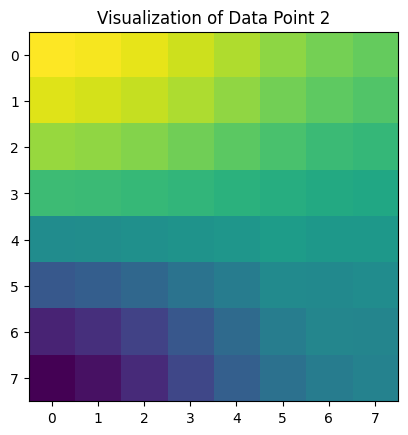

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data_point(data_dict, data_point_index=0):
  # Access the data
  data = data_dict["x_train"]
  data = np.array(data)

  # Select the specified data point
  single_data_point = data[data_point_index]

  # Reshape the selected data point
  reshaped_data = single_data_point.reshape(8, 8)

  # Display the image
  plt.imshow(reshaped_data)
  plt.title(f"Visualization of Data Point {data_point_index}")
  plt.show()

# Example usage:
visualize_data_point(model_linear_correlated_data_dict, data_point_index=2)  # Visualize the 5th data point

In [ ]:
model_translation_rotations_correlated_data_dict = torch.load("/content/translations_rotations_1d1p_0.2_correlated.pt")
model_translation_rotations_correlated_data_dict

<ipython-input-12-111d358f4c64>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_translation_rotations_correlated_data_dict = torch.load("/content/translations_rotatio

{'key': 'translations_rotations_1d1p_0.2_correlated',
 'x_train': tensor([[ 0.4595,  0.4404,  0.4080,  ..., -0.1689, -0.2634, -0.3142],
         [-0.3101, -0.2974, -0.2776,  ..., -0.3525, -0.3887, -0.4099],
         [ 0.2563,  0.2505,  0.2391,  ..., -0.0273, -0.0062,  0.0040],
         ...,
         [-0.3755, -0.3416, -0.2754,  ..., -0.1013, -0.0690, -0.0504],
         [ 0.2815,  0.2866,  0.2942,  ...,  0.3232,  0.3667,  0.3887],
         [ 0.3982,  0.3591,  0.2825,  ..., -0.0452, -0.1370, -0.1873]],
        dtype=torch.float16),
 'y_train': tensor([1, 0, 1,  ..., 0, 1, 1]),
 'x_val': tensor([[ 0.2632,  0.2465,  0.2146,  ..., -0.1736, -0.1750, -0.1769],
         [ 0.0969,  0.1147,  0.1398,  ...,  0.2212,  0.2101,  0.2062],
         [ 0.1387,  0.1186,  0.0786,  ..., -0.3198, -0.4014, -0.4480],
         ...,
         [-0.3328, -0.2930, -0.2234,  ...,  0.1348,  0.1749,  0.1970],
         [ 0.1990,  0.2280,  0.2766,  ...,  0.0288, -0.0140, -0.0379],
         [ 0.0448,  0.0611,  0.0883,  ..

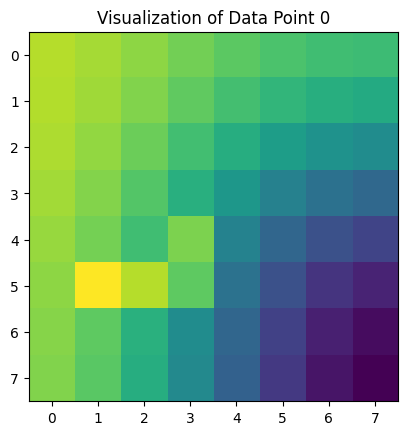

In [ ]:
visualize_data_point(model_translation_rotations_correlated_data_dict, data_point_index=0)

In [ ]:
model_translation_rotations_uncorrelated_data_dict = torch.load("/content/translations_rotations_1d1p_0.65_uncorrelated.pt")
model_translation_rotations_uncorrelated_data_dict

<ipython-input-14-f335265b95e1>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_translation_rotations_uncorrelated_data_dict = torch.load("/content/translations_rotat

{'key': 'translations_rotations_1d1p_0.65_uncorrelated',
 'x_train': tensor([[-0.0162, -0.0027, -0.0540,  ..., -0.0030,  0.0425, -0.1143],
         [-0.0236, -0.1549,  0.0338,  ..., -0.1254, -0.1119, -0.1359],
         [-0.0814,  0.0135,  0.1958,  ...,  0.1187, -0.0939, -0.0286],
         ...,
         [-0.0504,  0.0011, -0.1230,  ..., -0.0179,  0.0610, -0.0776],
         [-0.0036,  0.0872,  0.0794,  ...,  0.0920,  0.0346,  0.0721],
         [ 0.0034,  0.0305, -0.1365,  ..., -0.0421, -0.0359, -0.1650]],
        dtype=torch.float16),
 'y_train': tensor([1, 0, 1,  ..., 0, 1, 1]),
 'x_val': tensor([[-0.1382,  0.0942,  0.0806,  ...,  0.1558, -0.0497, -0.0390],
         [ 0.0271, -0.1252,  0.0818,  ..., -0.0641, -0.0989,  0.2163],
         [-0.0498,  0.0407,  0.0535,  ...,  0.0621, -0.1274, -0.0243],
         ...,
         [ 0.0666, -0.1146, -0.0162,  ...,  0.0135,  0.0067,  0.0579],
         [-0.0180,  0.0337, -0.0624,  ..., -0.0008,  0.0821, -0.0886],
         [-0.0109,  0.0555,  0.0371, 

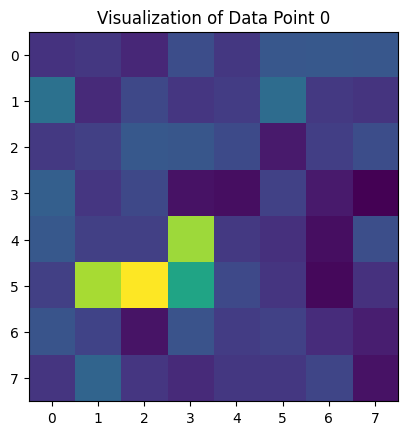

In [ ]:
visualize_data_point(model_translation_rotations_uncorrelated_data_dict, data_point_index=0)

In [ ]:
model_multiplicative_correlated_data_dict = torch.load("/content/multiplicative_1d1p_0.1_correlated.pt")
model_multiplicative_uncorrelated_data_dict = torch.load("/content/multiplicative_1d1p_0.7_uncorrelated.pt")
model_xor_correlated_data_dict = torch.load("/content/xor_1d1p_0.15_correlated.pt")
model_xor_uncorrelated_data_dict = torch.load("/content/xor_1d1p_0.35_uncorrelated.pt")

<ipython-input-17-e4ada79b14d9>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_multiplicative_correlated_data_dict = torch.load("/content/multiplicative_1d1p_0.1_cor

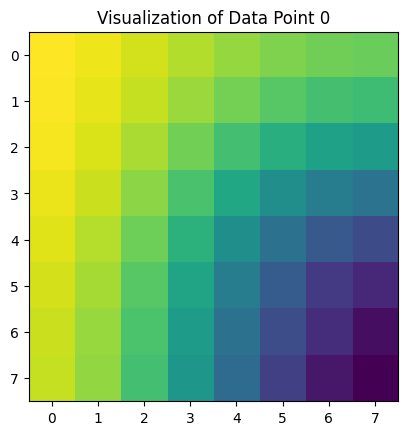

In [ ]:
visualize_data_point(model_multiplicative_correlated_data_dict, data_point_index=0)

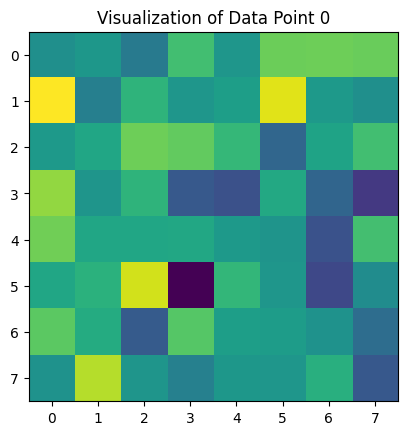

In [ ]:
visualize_data_point(model_multiplicative_uncorrelated_data_dict, data_point_index=0)

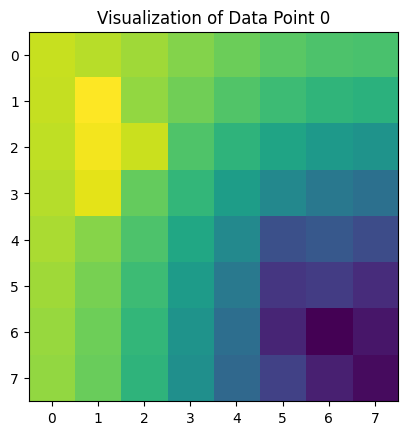

In [ ]:
visualize_data_point(model_xor_correlated_data_dict, data_point_index=0)

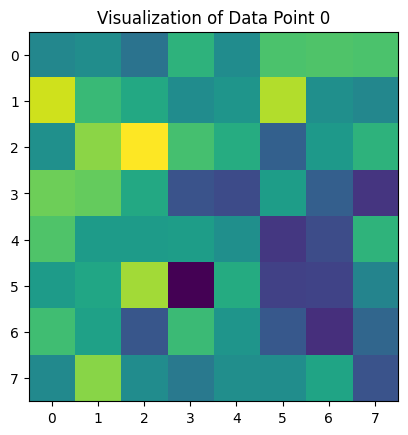

In [ ]:
visualize_data_point(model_xor_uncorrelated_data_dict, data_point_index=0)